In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
import os

print(os.listdir('/content'))

['.config', 'Electric_Vehicle_Population_Data.csv', 'sample_data']


In [4]:
df = pd.read_csv('/content/Electric_Vehicle_Population_Data.csv')

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJSA1E22K,King,Seattle,WA,98112.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270.0,0.0,43.0,202233958.0,POINT (-122.300312 47.629782),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,3MW39FS05R,Yakima,Zillah,WA,98953.0,2024,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20.0,0.0,15.0,264425178.0,POINT (-120.2658133 46.4063477),PACIFICORP,5.307700e+10
2,1N4AZ0CP0F,King,Kent,WA,98031.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,11.0,114962025.0,POINT (-122.201564 47.402358),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,5YJSA1H20F,Snohomish,Bothell,WA,98012.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,1.0,232724670.0,POINT (-122.206146 47.839957),PUGET SOUND ENERGY INC,5.306105e+10
4,JTMAB3FV1N,Yakima,Yakima,WA,98908.0,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,14.0,221023589.0,POINT (-120.611068 46.596645),PACIFICORP,5.307700e+10


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (150405, 17)

Columns:
Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

Missing Values:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      1
Electric Range            

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150405 entries, 0 to 150404
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         150405 non-null  object 
 1   County                                             150402 non-null  object 
 2   City                                               150402 non-null  object 
 3   State                                              150405 non-null  object 
 4   Postal Code                                        150402 non-null  float64
 5   Model Year                                         150405 non-null  int64  
 6   Make                                               150405 non-null  object 
 7   Model                                              150405 non-null  object 
 8   Electric Vehicle Type                              150405 non-null  object

In [7]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (150236, 17)


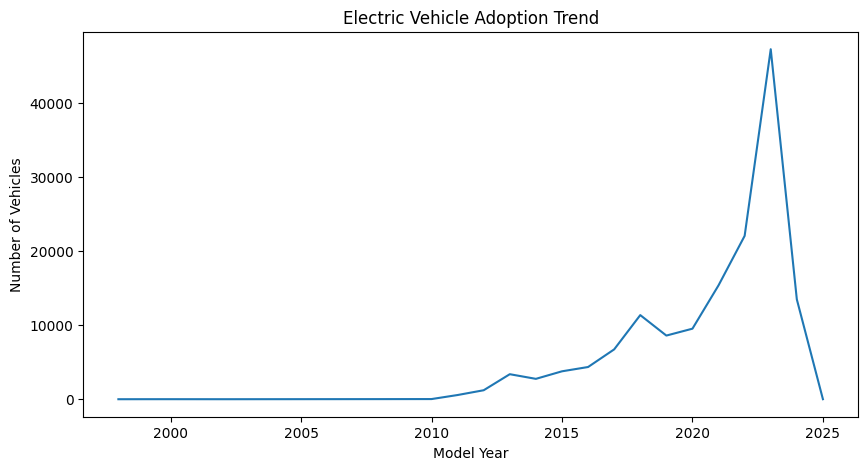

In [8]:
ev_year = df.groupby("Model Year").size()

plt.figure(figsize=(10,5))

plt.plot(ev_year.index, ev_year.values)

plt.title("Electric Vehicle Adoption Trend")

plt.xlabel("Model Year")

plt.ylabel("Number of Vehicles")

plt.show()

In [9]:
X = df[['Model Year']]

y = df['Electric Range']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [11]:
pred = model.predict(X_test)

print(pred[:10])

[ 7.00041966 37.16028525 97.48001642 37.16028525 22.08035246 67.32015084
 22.08035246 52.24021804 37.16028525 67.32015084]


In [12]:
mae = mean_absolute_error(y_test, pred)

r2 = r2_score(y_test, pred)

print("MAE:", mae)

print("R2 Score:", r2)

MAE: 55.5700988281043
R2 Score: 0.24897177210825683


In [13]:
features = ['Model Year','Base MSRP']

X = df[features]

y = df['Electric Range']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))

print("R2:",r2_score(y_test,pred))

MAE: 55.58579413938198
R2: 0.24902184973911312


In [15]:
future = pd.DataFrame({
'Model Year':[2026],
'Base MSRP':[50000]
})

prediction=model.predict(future)

print(
"Predicted Electric Range:",
prediction[0]
)

Predicted Electric Range: -26.568779462981183


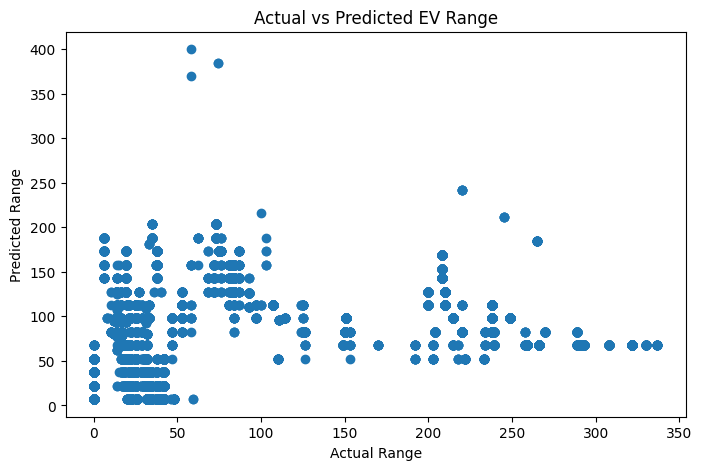

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
y_test,
pred
)

plt.xlabel(
"Actual Range"
)

plt.ylabel(
"Predicted Range"
)

plt.title(
"Actual vs Predicted EV Range"
)

plt.show()